# Test synthetic data function

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from modules.create_data import create_stroke_data

In [2]:
df = create_stroke_data(n=10000, seed=42)
df

,patient_id,age,ethnicity,male,warfarin,shoe_size,nihss,thrombolysis_time,thrombolysis,mortality_prob_no_treatment,mortality_odds_no_treatment,mortality_log_odds_no_treatment,mortality_prob_treated,mortality_odds_treated,mortality_log_odds_treated,odds_ratio_treated,log_odds_ratio_treated,probability_difference,mortality_probability,died
0,1,66,white,1,0,5,17,286.0,1,0.300,0.4286,-0.8473,0.2213,0.2842,-1.2582,1.5081,0.4109,0.0787,0.2213,1
1,2,79,white,1,0,7,15,99999.0,0,0.345,0.5267,-0.6411,0.3450,0.5267,-0.6411,1.0000,0.0000,-0.0000,0.3450,0
2,3,88,white,1,0,8,10,99999.0,0,0.340,0.5152,-0.6633,0.3400,0.5152,-0.6633,1.0000,0.0000,0.0000,0.3400,1
3,4,74,white,0,0,9,5,99999.0,0,0.170,0.2048,-1.5856,0.1700,0.2048,-1.5856,1.0000,0.0000,0.0000,0.1700,0
4,5,70,black,1,0,12,12,99999.0,0,0.370,0.5873,-0.5322,0.3700,0.5873,-0.5322,1.0000,0.0000,0.0000,0.3700,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,84,white,1,0,11,6,99999.0,0,0.280,0.3889,-0.9445,0.2800,0.3889,-0.9445,1.0000,0.0000,0.0000,0.2800,0
9996,9997,87,asian,0,0,10,21,76.0,1,0.445,0.8018,-0.2209,0.2669,0.3641,-1.0105,2.2024,0.7896,0.1781,0.2669,1
9997,9998,64,white,0,0,10,13,282.0,1,0.200,0.2500,-1.3863,0.1398,0.1625,-1.8171,1.5385,0.4308,0.0602,0.1398,0
9998,9999,83,white,0,0,10,11,99999.0,0,0.275,0.3793,-0.9694,0.2750,0.3793,-0.9694,1.0000,0.0000,0.0000,0.2750,0


In [3]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
patient_id,10000.0,5000.500,2886.896,1.000,2500.750,5000.500,7500.250,10000.000
age,10000.0,74.728,8.656,60.000,67.000,75.000,82.000,89.000
male,10000.0,0.516,0.500,0.000,0.000,1.000,1.000,1.000
warfarin,10000.0,0.194,0.396,0.000,0.000,0.000,0.000,1.000
shoe_size,10000.0,8.500,1.666,5.000,7.000,8.000,10.000,12.000
nihss,10000.0,12.799,6.219,0.000,8.000,12.000,17.000,29.000
thrombolysis_time,10000.0,70436.956,45571.001,30.000,308.000,99999.000,99999.000,99999.000
thrombolysis,10000.0,0.296,0.457,0.000,0.000,0.000,1.000,1.000
mortality_prob_no_treatment,10000.0,0.297,0.086,0.055,0.235,0.295,0.355,0.620
mortality_odds_no_treatment,10000.0,0.445,0.189,0.058,0.307,0.418,0.550,1.632


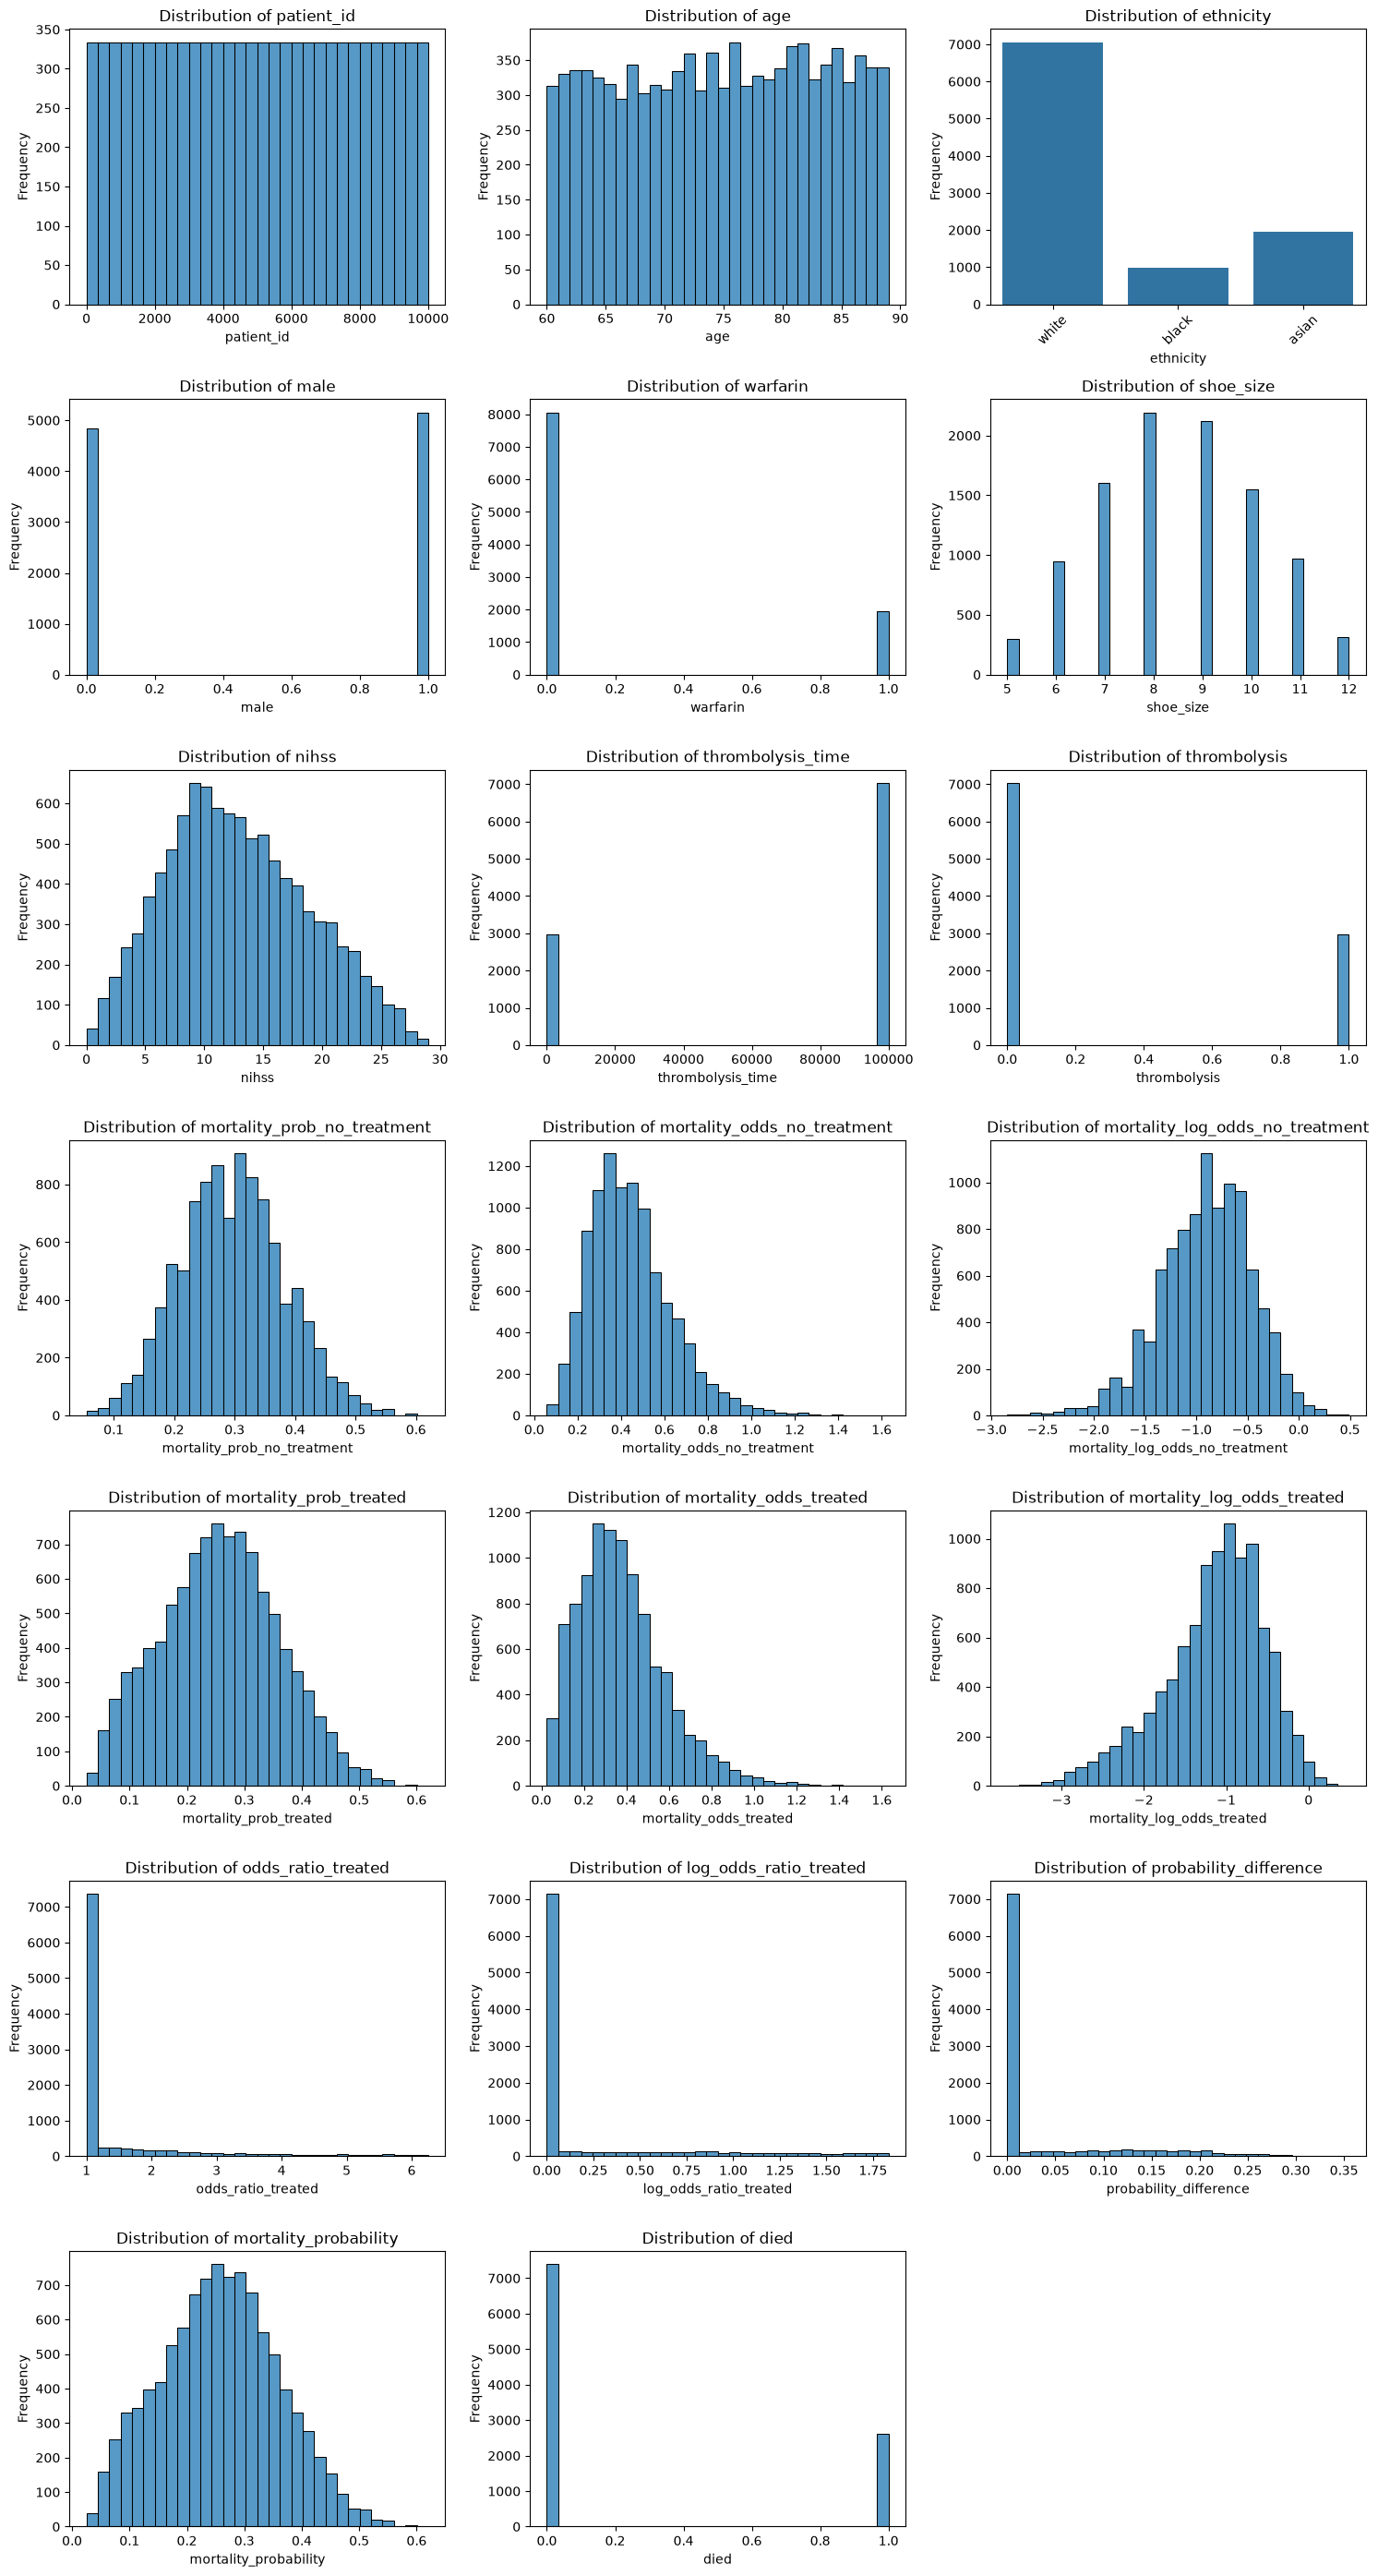

In [5]:
import math

# Plot the distributions of all the variables in the dataset

ncols = 3
nrows = math.ceil(len(df.columns) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.ravel()

for ax, col in zip(axes, df.columns):
    if pd.api.types.is_numeric_dtype(df[col]):
        sns.histplot(data=df, x=col, kde=False, bins=30, ax=ax)
    else:
        sns.countplot(data=df, x=col, ax=ax)
        ax.tick_params(axis="x", rotation=45)

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

for ax in axes[len(df.columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()